In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import h5py
import re

f5 = '/Users/lilywatanabe/Desktop/eth/thesis/SPH-EXA-fork/output/run_disk_1J_5000.hdf5'
f5_double = '/Users/lilywatanabe/Desktop/eth/thesis/SPH-EXA-fork/output/run_disk_2J_5000.hdf5'
f5_half = '/Users/lilywatanabe/Desktop/eth/thesis/SPH-EXA-fork/output/run_disk_05J_5000.hdf5'
plots = '/Users/lilywatanabe/Desktop/eth/thesis/SPH-EXA-fork/output/plots/'

# constants
G = 1 
G2 = G * G

In [2]:
# extract data from hdf5 file with optional stride 
# returns arrays of selected keys (based on stride), density, pressure, x, y and z coords of particles & star
def read_hdf5_data(file, stride=1):
    densities = []
    pressures = []
    masses = []
    x_pos = []
    y_pos = []
    z_pos = []
    times = []
    star_x = []
    star_y = []
    star_z = []
    star_m = []

    with h5py.File(file, 'r') as f: 
        step_keys = sorted(f.keys(), key=lambda x: int(re.search(r'\d+', x).group()))
        selected_keys = step_keys[::stride]
        
        # extract all star mass and sound speed data
        for step_key in selected_keys:
            densities.append(np.array(f[step_key]['rho']))
            pressures.append(np.array(f[step_key]['p']))
            masses.append(np.array(f[step_key]['m']))
            x_pos.append(np.array(f[step_key]['x']))
            y_pos.append(np.array(f[step_key]['y']))
            z_pos.append(np.array(f[step_key]['z']))
            times.append(np.array(f[step_key].attrs['time']))
            star_x.append(np.array(f[step_key].attrs['star::x']))
            star_y.append(np.array(f[step_key].attrs['star::y']))
            star_z.append(np.array(f[step_key].attrs['star::z']))
            star_m.append(np.array(f[step_key].attrs['star::m']))

    return selected_keys, densities, pressures, masses, x_pos, y_pos, z_pos, times, star_x, star_y, star_z, star_m

In [58]:
# shortened version  
def particle_radii2(x, y, z, m, star_x, star_y, star_z, star_m, timesteps): 
    num_timesteps = len(timesteps)
    # Initialize lists to hold the arrays for each time step
    radii = []
    disk_particles = []

    for step in range(num_timesteps):
        nr_particles = len(x[step])  # Number of particles at this time step
        # Create numpy arrays for this time step
        step_radii = np.zeros(nr_particles)  # Initialize with zeros
        step_disk_particles = np.zeros(nr_particles, dtype=bool)  # Boolean array for selection
        
        # Calculate the radii for each particle at this step
        step_radii[:] = np.sqrt((x[step] - star_x[step])**2 + 
                                 (y[step] - star_y[step])**2 + 
                                 (z[step] - star_z[step])**2)
        print("step radius: ", step_radii, "\n")
        # Mark disk particles based on the threshold
        threshold_radius = step_radii * np.cbrt(m[step]/star_m[step])
        print("threshold radius: ", threshold_radius, "\n")
        # print("thresholding factor: ", np.cbrt(m[step]/star_m[step]), "\n")
        # step_disk_particles[:] = step_radii < (100.5 * threshold_radius)
        step_disk_particles[:] = True

        # Append the results for this step to the lists
        radii.append(step_radii)
        disk_particles.append(step_disk_particles)
    # print(radii, "\n", disk_particles, "\n")
    print("len of radii: ", len(radii), " len of disk_particles: ", len(disk_particles))
    return radii, disk_particles

In [65]:
def surface_density(timesteps, rho, z, disk_mask): 
    num_ts = len(timesteps)
    sigma = []

    for step in range(num_ts): 
        sigma.append(np.sum(rho[step][disk_mask[step]] * z[step][disk_mask[step]]))

    return sigma

In [14]:
def plot_density(t, x, y, z, star_x, star_y, star_z, densities, disk_mask):
    x_disk = x[t][disk_mask[t]]
    y_disk = y[t][disk_mask[t]]
    z_disk = z[t][disk_mask[t]]
    densities_disk = densities[t][disk_mask[t]]
    print("Filtered X values:", x_disk)
    print("Filtered Y values:", y_disk)
    print("Filtered Z values:", z_disk)
    print("Filtered Densities:", densities_disk)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(x_disk, y_disk, z_disk, c=densities_disk, cmap='viridis', s=1)
    plt.colorbar(scatter, label='Density')
    ax.plot(star_x[t], star_y[t], star_z[t], color = 'red')
    ax.set_title(f'Density Distribution in 3D at timestep {t}')
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_zlabel('Z Position')
    ax.set_xlim([np.min(x_disk), np.max(x_disk)])
    ax.set_ylim([np.min(y_disk), np.max(y_disk)])
    ax.set_zlim([np.min(z_disk), np.max(z_disk)])
    fname = f'density_distribution_1J.png'
    plt.savefig(plots + fname)
    plt.show()

In [13]:
def plot_pressure(t, x, y, z, star_x, star_y, star_z, pressures, disk_mask):
    x_disk = x[t][disk_mask[t]]
    y_disk = y[t][disk_mask[t]]
    z_disk = z[t][disk_mask[t]]
    pressures_disk = pressures[t][disk_mask[t]]
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(x_disk, y_disk, z_disk, c=pressures_disk, cmap='viridis', s=1)
    plt.colorbar(scatter, label='Pressure')
    ax.plot(star_x[t], star_y[t], star_z[t], color = 'red')

    ax.set_title(f'Pressure Distribution in 3D at timestep {t}')
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_zlabel('Z Position')
    ax.set_xlim([np.min(x_disk), np.max(x_disk)])
    ax.set_ylim([np.min(y_disk), np.max(y_disk)])
    ax.set_zlim([np.min(z_disk), np.max(z_disk)])
    fname = f'pressure_distribution_1J.png'
    plt.savefig(plots + fname)
    plt.show()

In [57]:
def plot_surface_density(t, sigma): 
    plt.figure()
    plt.scatter(t, sigma, label='surface density of disk', color='blue', marker='.')
    plt.title('Surface Density of Inner Disk over Time')
    plt.xlabel('Time (yr)')
    plt.ylabel('Surface Density')
    plt.grid()
    plt.legend()
    fname = f'surface density_1J.png'
    plt.savefig(plots + fname)
    plt.show()
    

In [6]:

ts, d, p, m, x, y, z, times, sx, sy, sz, sm = read_hdf5_data(f5,1)

In [59]:
r, disk_particles = particle_radii2(x, y, z, m, sx, sy, sz, sm, ts)

step radius:  [6.30164617 6.10404659 5.95812634 ... 5.23156311 5.05901305 4.85794466] 

threshold radius:  [0.06301646 0.06104047 0.05958126 ... 0.05231563 0.05059013 0.04857945] 

step radius:  [6.3016457  6.10404624 5.9581253  ... 5.23156185 5.05901117 4.85794245] 

threshold radius:  [0.06258177 0.0606194  0.05917026 ... 0.05195474 0.05024114 0.04824432] 

step radius:  [5.59834015 6.30164373 6.10404453 ... 5.23156197 5.05901018 4.85794075] 

threshold radius:  [0.05558242 0.06256508 0.06060324 ... 0.05194091 0.05022775 0.04823146] 

step radius:  [5.59833629 6.30164192 6.10404314 ... 5.23156187 5.05900836 4.85793786] 

threshold radius:  [0.05558144 0.062564   0.0606022  ... 0.05194003 0.05022688 0.04823061] 

step radius:  [5.59833171 6.30164035 5.95811463 ... 5.2315615  5.05900553 4.85793352] 

threshold radius:  [0.05558098 0.06256352 0.05915295 ... 0.05193963 0.05022648 0.04823021] 

step radius:  [5.59832623 6.3016391  5.95810981 ... 5.2315608  5.05900143 4.85792735] 

thresho

In [66]:
sigma = surface_density(ts, d, z, disk_particles)

Filtered X values: [-5.77323017 -5.38322142 -4.86505306 ...  4.67287729  4.89473326
  5.74814821]
Filtered Y values: [-3.56364174 -3.95888607 -4.05061471 ... -3.88530564 -3.94093306
 -3.63812596]
Filtered Z values: [-1.43911311 -1.14812191 -1.22196457 ... -1.40499306 -1.11513443
 -1.44726013]
Filtered Densities: [4.84751987e-06 8.75600017e-06 1.61677034e-05 ... 1.30379308e-05
 1.60021556e-05 4.03621847e-06]


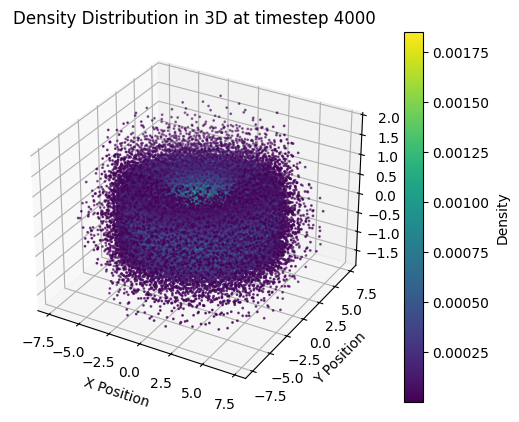

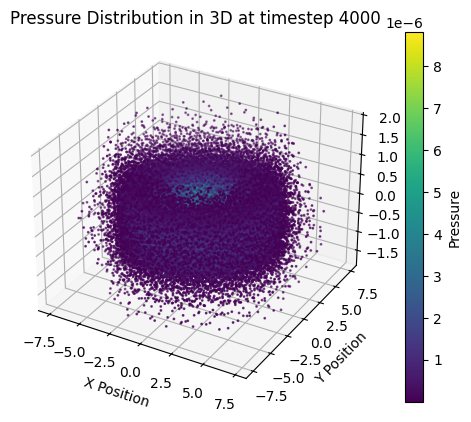

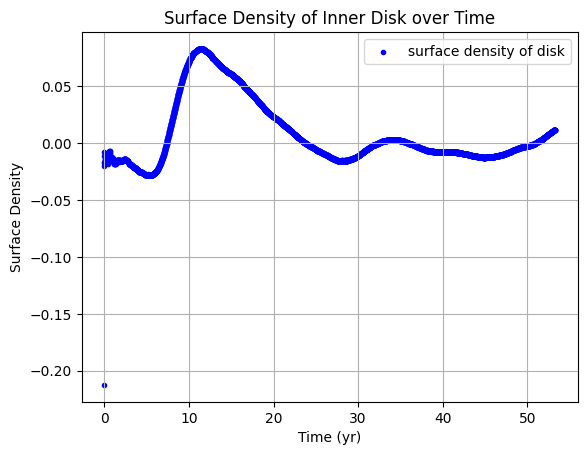

In [67]:
plot_density(4000, x, y, z, sx, sy, sz, d, disk_particles)
plot_pressure(4000, x, y, z, sx, sy, sz, p, disk_particles)
plot_surface_density(times, sigma)